# Notebook 08: Final Visualisations & Framework Summary

## Purpose
This notebook produces the summary dashboard bringing together all analytical components into a unified forensic linguistic framework, and exports data for MATLAB visualisation.

## Objectives Addressed
- **Objective 8**: Visualise anomalies, topic shifts, and communication irregularities over time
- **Objective 9**: Evaluate the effectiveness and limitations of the framework for forensic intelligence

## Key Outputs
- Framework overview dashboard combining all analyses
- Anomaly scores CSV exported for MATLAB
- Summary visualisation suitable for inclusion in dissertation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_pickle('../data/processed/emails_with_anomalies.pkl')
style_df = pd.read_pickle('../data/features/stylistic_features.pkl')
print(f"Loaded {len(df):,} emails")

Loaded 458,386 emails


## 8.1 Data Export for MATLAB
Anomaly scores, stylistic features, and topic assignments are exported as a CSV file for additional visualisation in MATLAB. This demonstrates the framework's interoperability across different analytical tools.

In [2]:
# Export anomaly scores for MATLAB
export = pd.DataFrame({
    'user': df['user'],
    'date': df['datetime'].astype(str),
    'anomaly_score': df['anomaly_score'],
    'anomaly_iso': df['anomaly_iso'],
    'anomaly_lof': df['anomaly_lof'],
    'strong_anomaly': df['strong_anomaly'],
    'dominant_topic': df['dominant_topic'],
    'avg_word_length': style_df['avg_word_length'],
    'vocab_richness': style_df['vocab_richness'],
    'num_words': style_df['num_words'],
})
export.to_csv('../results/anomaly_scores.csv', index=False)
print("Exported anomaly scores for MATLAB")

Exported anomaly scores for MATLAB


## 8.2 Framework Overview Dashboard
The dashboard combines five key visualisations into a single figure summarising the entire forensic linguistic framework: email volume over time with key event markers, the most anomalous users identified through blind analysis, anomaly rate escalation during the crisis period, topic distribution across the corpus, and vocabulary richness trajectories for persons of interest. Together, these demonstrate that unsupervised NLP methods can surface forensically relevant patterns from unstructured email evidence.

/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78670/2344028864.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['datetime'].dt.to_period('M')).size()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78670/2344028864.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_rate = df.groupby(df['datetime'].dt.to_period('M'))['strong_anomaly'].mean()


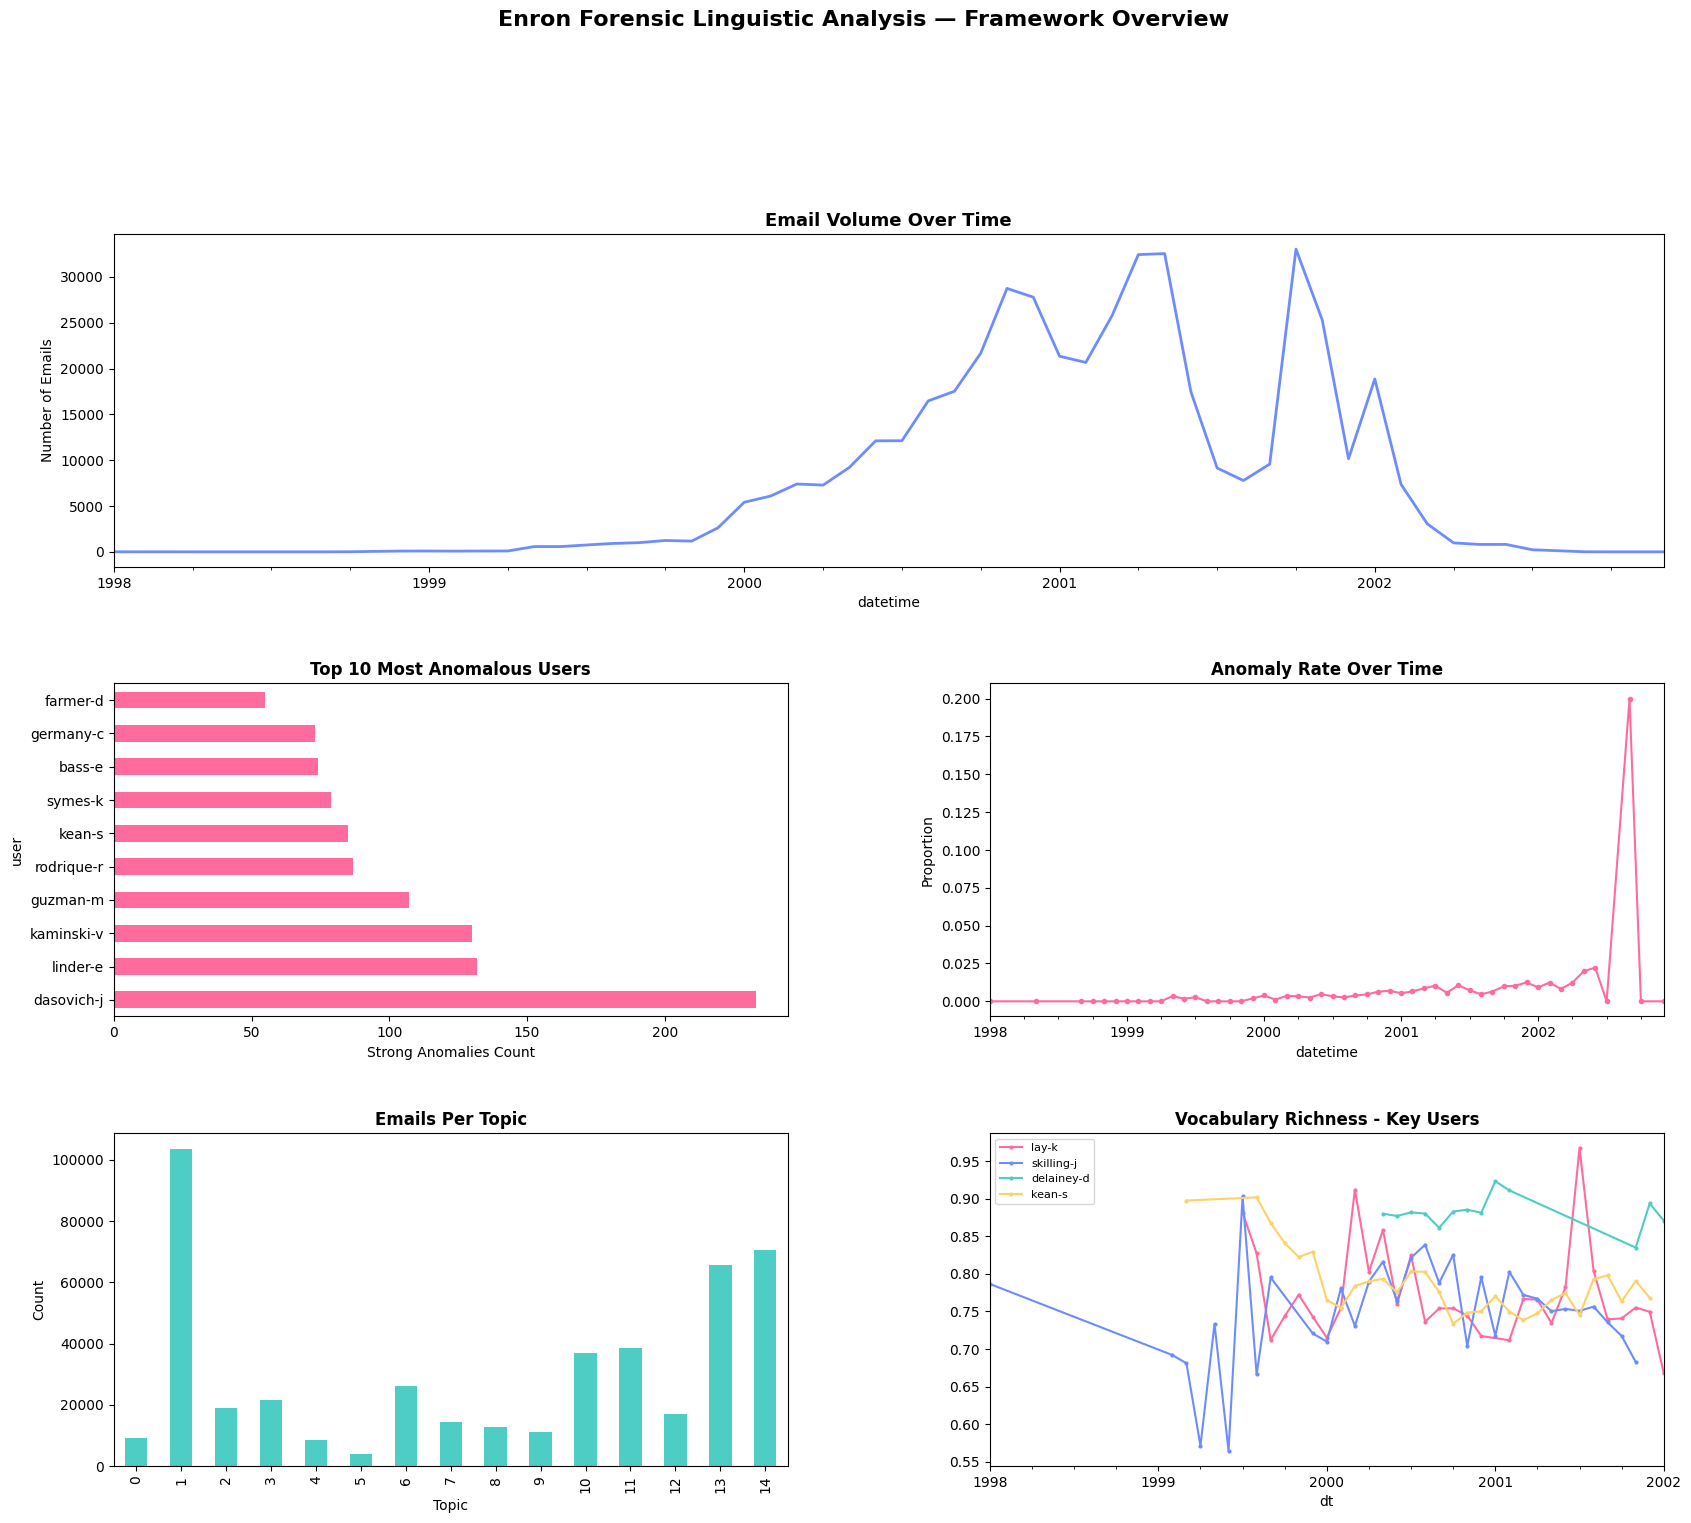

In [3]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Email volume timeline
ax1 = fig.add_subplot(gs[0, :])
monthly = df.groupby(df['datetime'].dt.to_period('M')).size()
monthly.plot(ax=ax1, color='#6c8cff', linewidth=2)
ax1.set_title('Email Volume Over Time', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Emails')
for date, event in {'2001-08': 'Skilling resigns', '2001-10': 'SEC investigation', '2001-12': 'Bankruptcy'}.items():
    try:
        ax1.axvline(x=monthly.index.get_loc(date), color='red', linestyle='--', alpha=0.7)
    except:
        pass

# Panel 2: Anomaly distribution by user
ax2 = fig.add_subplot(gs[1, 0])
anomaly_by_user = df[df['strong_anomaly']]['user'].value_counts().head(10)
anomaly_by_user.plot(kind='barh', ax=ax2, color='#ff6b9d')
ax2.set_title('Top 10 Most Anomalous Users', fontweight='bold')
ax2.set_xlabel('Strong Anomalies Count')

# Panel 3: Anomaly rate over time
ax3 = fig.add_subplot(gs[1, 1])
monthly_rate = df.groupby(df['datetime'].dt.to_period('M'))['strong_anomaly'].mean()
monthly_rate.plot(ax=ax3, color='#ff6b9d', marker='o', markersize=3)
ax3.set_title('Anomaly Rate Over Time', fontweight='bold')
ax3.set_ylabel('Proportion')

# Panel 4: Topic distribution
ax4 = fig.add_subplot(gs[2, 0])
df['dominant_topic'].value_counts().sort_index().plot(kind='bar', ax=ax4, color='#4ecdc4')
ax4.set_title('Emails Per Topic', fontweight='bold')
ax4.set_xlabel('Topic')
ax4.set_ylabel('Count')

# Panel 5: Writing style - key users vs average
ax5 = fig.add_subplot(gs[2, 1])
key_users = ['lay-k', 'skilling-j', 'delainey-d', 'kean-s']
colors = ['#ff6b9d', '#6c8cff', '#4ecdc4', '#ffd166']
for user, color in zip(key_users, colors):
    user_mask = df['user'] == user
    user_data = df[user_mask]
    monthly_wl = style_df[user_mask].assign(dt=user_data['datetime'].values).groupby(
        pd.to_datetime(style_df[user_mask].assign(dt=user_data['datetime'].values)['dt']).dt.to_period('M')
    )['vocab_richness'].mean()
    monthly_wl.plot(ax=ax5, color=color, marker='o', markersize=2, label=user)
ax5.set_title('Vocabulary Richness - Key Users', fontweight='bold')
ax5.legend(fontsize=8)

plt.suptitle('Enron Forensic Linguistic Analysis — Framework Overview',
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../results/figures/framework_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
df.to_pickle('../data/processed/emails_with_anomalies.pkl')
print("All done - framework complete")

All done - framework complete


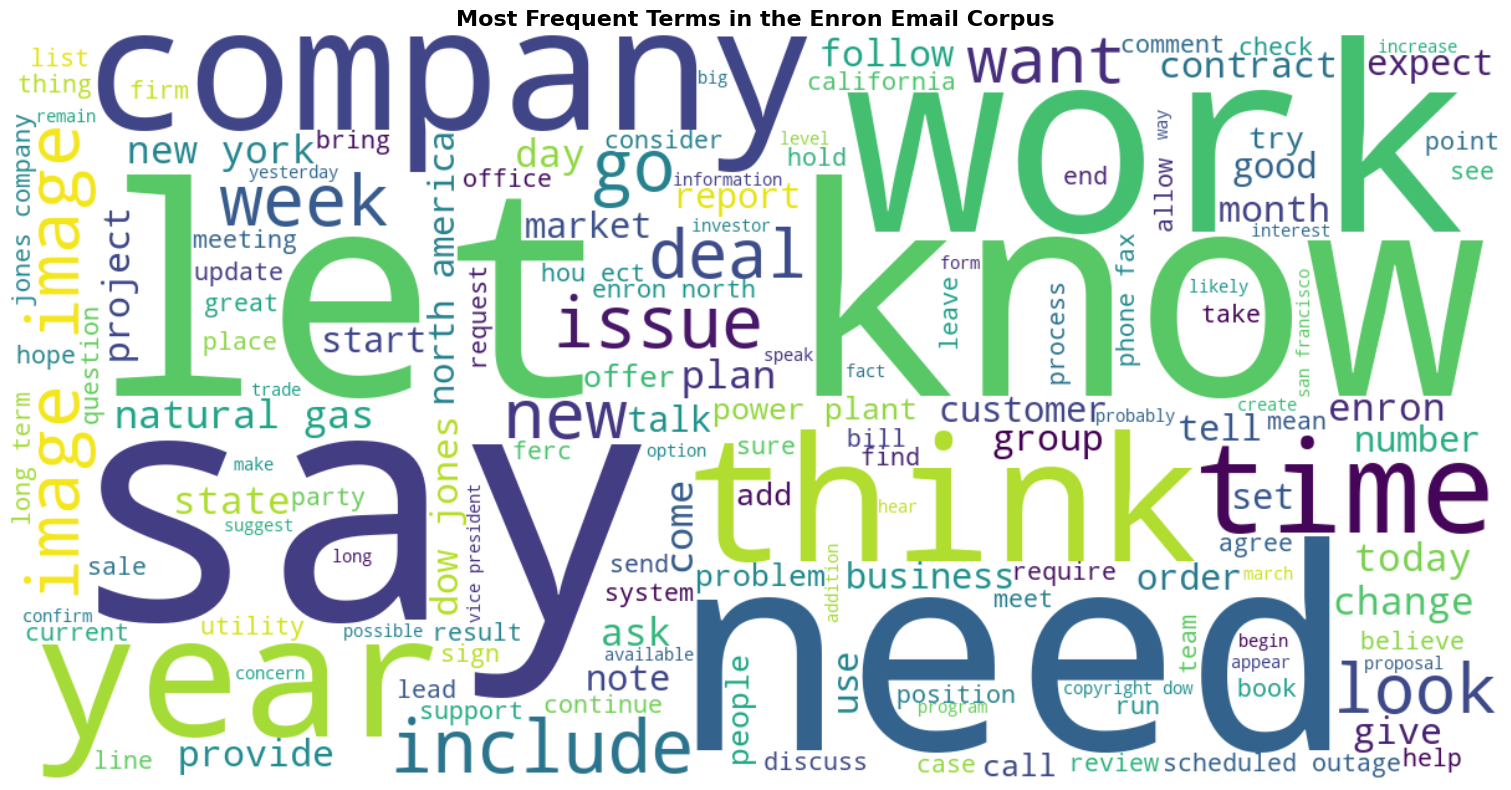

In [2]:
from wordcloud import WordCloud

# Word cloud of most common terms
all_text = ' '.join(df['processed_text'].dropna().sample(50000, random_state=42))
wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=150,
    colormap='viridis'
).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Terms in the Enron Email Corpus', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/wordcloud.png', dpi=150)
plt.show()

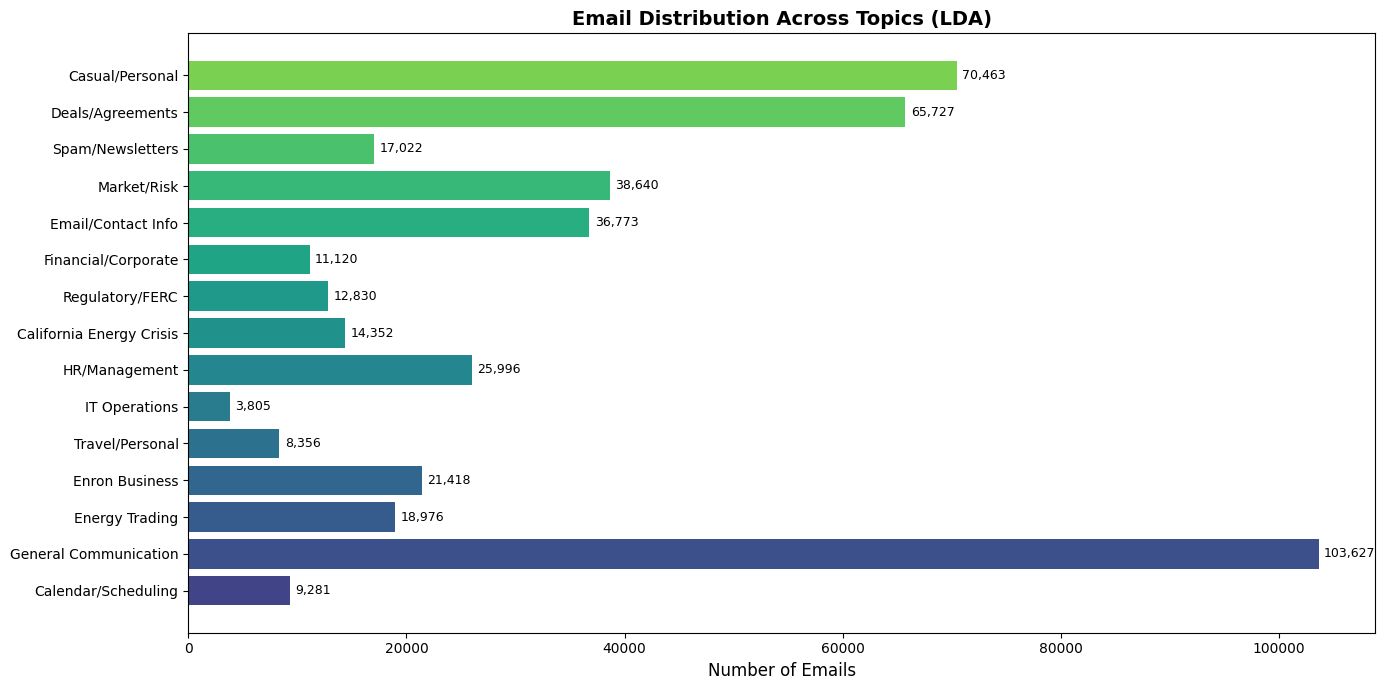

In [3]:
# Topic distribution with descriptive labels
topic_labels = {
    0: 'Calendar/Scheduling',
    1: 'General Communication',
    2: 'Energy Trading',
    3: 'Enron Business',
    4: 'Travel/Personal',
    5: 'IT Operations',
    6: 'HR/Management',
    7: 'California Energy Crisis',
    8: 'Regulatory/FERC',
    9: 'Financial/Corporate',
    10: 'Email/Contact Info',
    11: 'Market/Risk',
    12: 'Spam/Newsletters',
    13: 'Deals/Agreements',
    14: 'Casual/Personal'
}

topic_counts = df['dominant_topic'].value_counts().sort_index()
labels = [topic_labels[i] for i in topic_counts.index]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(labels, topic_counts.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, 15)))
ax.set_xlabel('Number of Emails', fontsize=12)
ax.set_title('Email Distribution Across Topics (LDA)', fontsize=14, fontweight='bold')

for i, v in enumerate(topic_counts.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/topic_distribution_labelled.png', dpi=150)
plt.show()

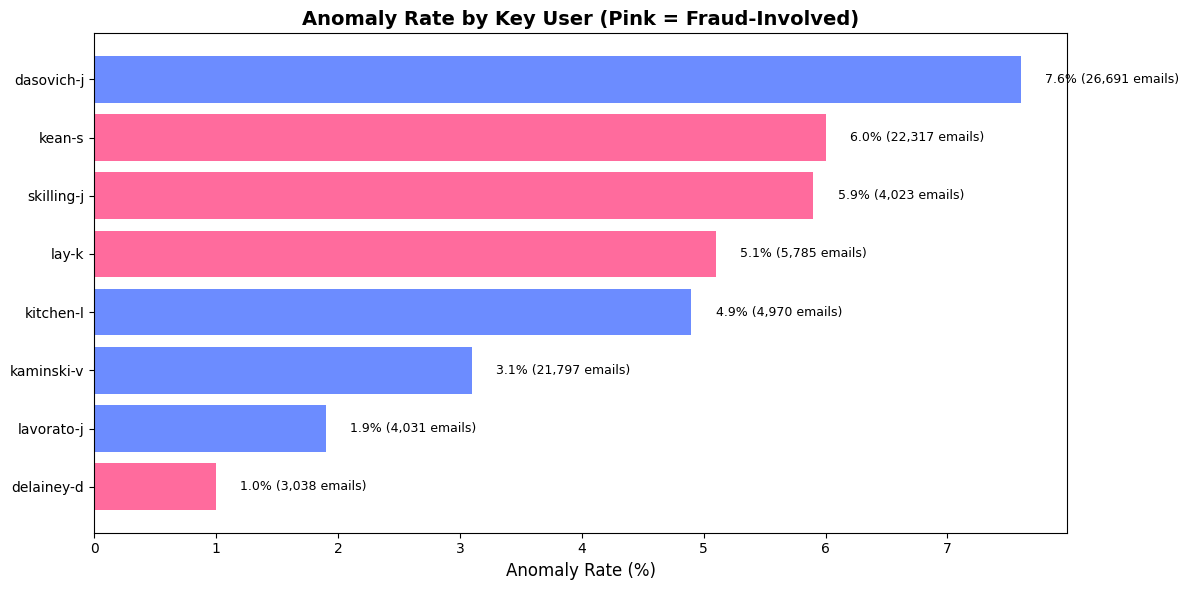

In [4]:
# Key users anomaly summary table
key_users = ['lay-k', 'skilling-j', 'fastow-a', 'delainey-d', 'kean-s', 
             'kitchen-l', 'lavorato-j', 'dasovich-j', 'kaminski-v']

summary_data = []
for user in key_users:
    user_data = df[df['user'] == user]
    if len(user_data) == 0:
        continue
    summary_data.append({
        'User': user,
        'Total Emails': len(user_data),
        'ISO Forest Anomalies': (user_data['anomaly_iso'] == -1).sum(),
        'LOF Anomalies': (user_data['anomaly_lof'] == -1).sum(),
        'Strong Anomalies': user_data['strong_anomaly'].sum(),
        'Anomaly Rate %': round((user_data['anomaly_iso'] == -1).sum() / len(user_data) * 100, 1)
    })

summary_df = pd.DataFrame(summary_data).sort_values('Anomaly Rate %', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#ff6b9d' if user in ['lay-k', 'skilling-j', 'fastow-a', 'delainey-d', 'kean-s'] 
          else '#6c8cff' for user in summary_df['User']]
bars = ax.barh(summary_df['User'], summary_df['Anomaly Rate %'], color=colors)
ax.set_xlabel('Anomaly Rate (%)', fontsize=12)
ax.set_title('Anomaly Rate by Key User (Pink = Fraud-Involved)', fontsize=14, fontweight='bold')

for i, (rate, total) in enumerate(zip(summary_df['Anomaly Rate %'], summary_df['Total Emails'])):
    ax.text(rate + 0.2, i, f'{rate}% ({total:,} emails)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/key_users_anomaly_rates.png', dpi=150)
plt.show()

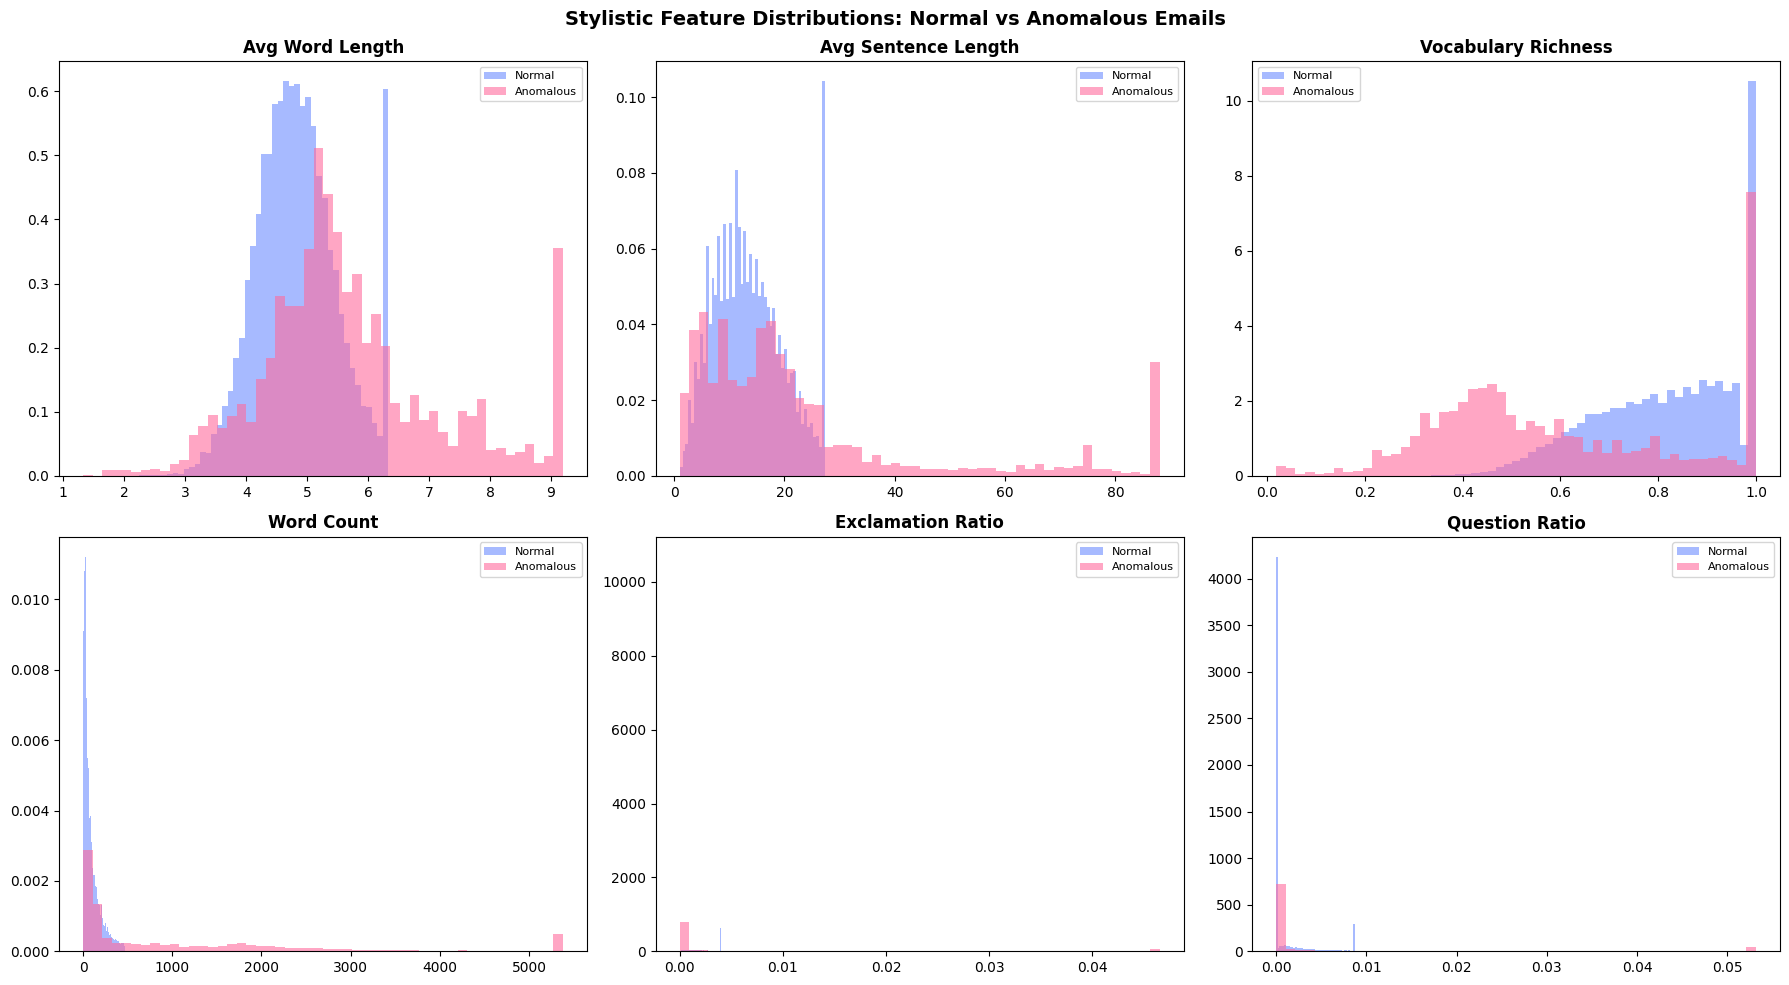

In [5]:
# Stylistic features comparison: anomalous vs normal emails
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = ['avg_word_length', 'avg_sentence_length', 'vocab_richness', 
            'num_words', 'exclamation_ratio', 'question_ratio']
feature_labels = ['Avg Word Length', 'Avg Sentence Length', 'Vocabulary Richness',
                  'Word Count', 'Exclamation Ratio', 'Question Ratio']

normal = style_df[df['anomaly_iso'] == 1]
anomalous = style_df[df['anomaly_iso'] == -1]

for ax, feat, label in zip(axes.flat, features, feature_labels):
    ax.hist(normal[feat].clip(upper=normal[feat].quantile(0.95)), bins=50, 
            alpha=0.6, color='#6c8cff', label='Normal', density=True)
    ax.hist(anomalous[feat].clip(upper=anomalous[feat].quantile(0.95)), bins=50, 
            alpha=0.6, color='#ff6b9d', label='Anomalous', density=True)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Stylistic Feature Distributions: Normal vs Anomalous Emails', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/stylistic_features_comparison.png', dpi=150)
plt.show()

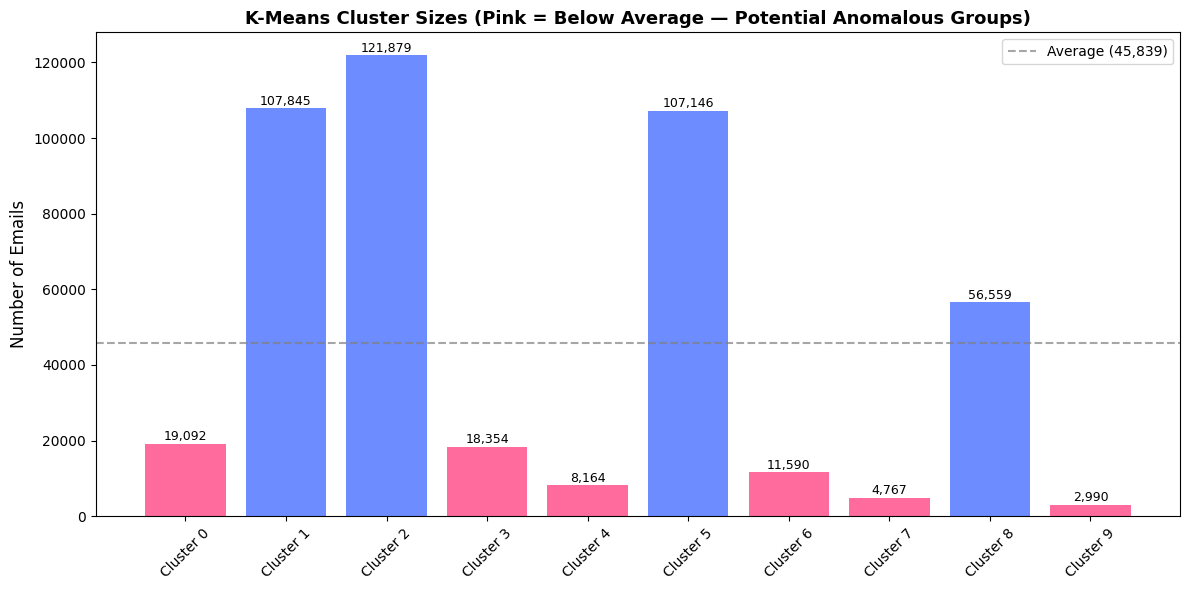

In [6]:
# K-Means cluster sizes
cluster_counts = df['cluster'].value_counts().sort_index()
avg_size = cluster_counts.mean()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#ff6b9d' if count < avg_size else '#6c8cff' for count in cluster_counts.values]
bars = ax.bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values, color=colors)
ax.axhline(y=avg_size, color='gray', linestyle='--', alpha=0.7, label=f'Average ({avg_size:,.0f})')
ax.set_ylabel('Number of Emails', fontsize=12)
ax.set_title('K-Means Cluster Sizes (Pink = Below Average — Potential Anomalous Groups)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

for i, v in enumerate(cluster_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/figures/cluster_sizes.png', dpi=150)
plt.show()

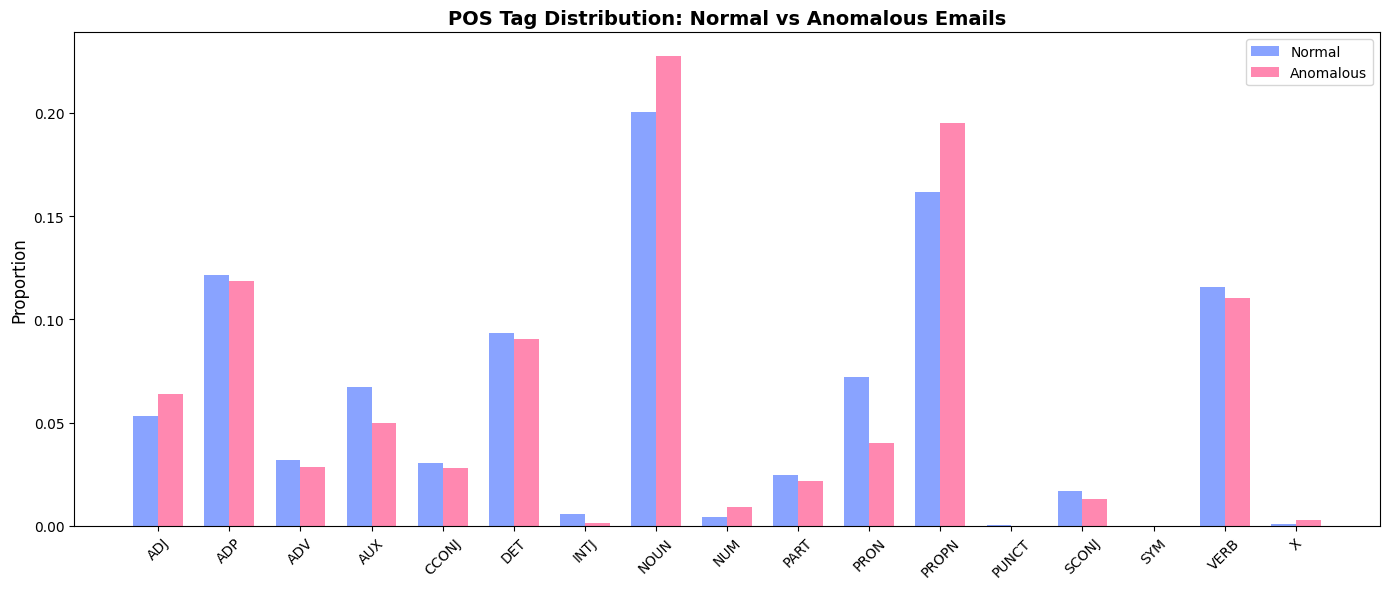

In [8]:
# POS tag distribution for normal vs anomalous emails
import spacy
nlp_pos = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# Sample 500 normal and 500 anomalous emails for POS analysis
normal_sample = df[df['anomaly_iso'] == 1].sample(500, random_state=42)
anomalous_sample = df[df['anomaly_iso'] == -1].sample(500, random_state=42)

def get_pos_dist(texts):
    pos_counts = {}
    total = 0
    for doc in nlp_pos.pipe(texts, batch_size=100):
        for token in doc:
            if token.is_alpha:
                pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1
                total += 1
    return {k: v/total for k, v in pos_counts.items()}

normal_pos = get_pos_dist(normal_sample['clean_body'].tolist())
anomalous_pos = get_pos_dist(anomalous_sample['clean_body'].tolist())

# Plot
pos_tags = sorted(set(list(normal_pos.keys()) + list(anomalous_pos.keys())))
normal_vals = [normal_pos.get(t, 0) for t in pos_tags]
anomalous_vals = [anomalous_pos.get(t, 0) for t in pos_tags]

x = np.arange(len(pos_tags))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, normal_vals, width, label='Normal', color='#6c8cff', alpha=0.8)
ax.bar(x + width/2, anomalous_vals, width, label='Anomalous', color='#ff6b9d', alpha=0.8)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('POS Tag Distribution: Normal vs Anomalous Emails', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pos_tags, rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/pos_distribution_comparison.png', dpi=150)
plt.show()

In [10]:
import os
print("All new figures saved to results/figures/")
print(f"Total figures: {len([f for f in os.listdir('../results/figures/') if f.endswith('.png')])}")

All new figures saved to results/figures/
Total figures: 16
